Libraries Importing and Data Importing

In [3]:
import pandas as pd
import numpy as np

In [4]:
df = pd.read_csv("C:\\Users\\ABHISHEK\\Desktop\\ecommerce-sales-monitoring-alert-system\\Data\\retail_store_inventory.csv")

In [5]:
df.shape

(73100, 16)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 73100 entries, 0 to 73099
Data columns (total 16 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Date                73100 non-null  object 
 1   Store ID            73100 non-null  object 
 2   Product ID          73100 non-null  object 
 3   Category            73100 non-null  object 
 4   Region              73100 non-null  object 
 5   Inventory Level     73100 non-null  int64  
 6   Units Sold          73100 non-null  int64  
 7   Units Ordered       73100 non-null  int64  
 8   Demand Forecast     73100 non-null  float64
 9   Price               73100 non-null  float64
 10  Discount            73100 non-null  int64  
 11  Weather Condition   73100 non-null  object 
 12  Holiday/Promotion   73100 non-null  int64  
 13  Competitor Pricing  73100 non-null  float64
 14  Seasonality         73100 non-null  object 
 15  Product_Name        73100 non-null  object 
dtypes: f

In [7]:
df.describe()

,Inventory Level,Units Sold,Units Ordered,Demand Forecast,Price,Discount,Holiday/Promotion,Competitor Pricing
count,73100.000000,73100.000000,73100.000000,73100.000000,73100.000000,73100.000000,73100.000000,73100.000000
mean,274.469877,136.464870,110.004473,141.494720,55.135108,10.009508,0.497305,55.146077
std,129.949514,108.919406,52.277448,109.254076,26.021945,7.083746,0.499996,26.191408
min,50.000000,0.000000,20.000000,-9.990000,10.000000,0.000000,0.000000,5.030000
25%,162.000000,49.000000,65.000000,53.670000,32.650000,5.000000,0.000000,32.680000
50%,273.000000,107.000000,110.000000,113.015000,55.050000,10.000000,0.000000,55.010000
75%,387.000000,203.000000,155.000000,208.052500,77.860000,15.000000,1.000000,77.820000
max,500.000000,499.000000,200.000000,518.550000,100.000000,20.000000,1.000000,104.940000


In [8]:
df.isnull().sum()

Date                  0
Store ID              0
Product ID            0
Category              0
Region                0
Inventory Level       0
Units Sold            0
Units Ordered         0
Demand Forecast       0
Price                 0
Discount              0
Weather Condition     0
Holiday/Promotion     0
Competitor Pricing    0
Seasonality           0
Product_Name          0
dtype: int64

In [9]:
df.dtypes

Date                   object
Store ID               object
Product ID             object
Category               object
Region                 object
Inventory Level         int64
Units Sold              int64
Units Ordered           int64
Demand Forecast       float64
Price                 float64
Discount                int64
Weather Condition      object
Holiday/Promotion       int64
Competitor Pricing    float64
Seasonality            object
Product_Name           object
dtype: object

In [10]:
# fix the date datatype 
# Convert Date column to datetime
df['Date'] = pd.to_datetime(df['Date'], errors='coerce')




In [11]:
df['Date'].isnull().sum()

44200

In [12]:
df['Date'] = pd.to_datetime(df['Date'], errors='coerce')
df['Date'] = df['Date'].fillna(method='ffill')

C:\Users\ABHISHEK\AppData\Local\Temp\ipykernel_7200\1802533026.py:2: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df['Date'] = df['Date'].fillna(method='ffill')


In [13]:
df['Date'].isnull().sum()

0

In [14]:
df.info

<bound method DataFrame.info of             Date Store ID Product ID     Category Region  Inventory Level  \
0     2022-01-01     S001      P0001    Groceries  North              231   
1     2022-01-01     S001      P0002         Toys  South              204   
2     2022-01-01     S001      P0003         Toys   West              102   
3     2022-01-01     S001      P0004         Toys  North              469   
4     2022-01-01     S001      P0005  Electronics   East              166   
...          ...      ...        ...          ...    ...              ...   
73095 2024-01-01     S005      P0016    Furniture   East               96   
73096 2024-01-01     S005      P0017         Toys  North              313   
73097 2024-01-01     S005      P0018     Clothing   West              278   
73098 2024-01-01     S005      P0019         Toys   East              374   
73099 2024-01-01     S005      P0020    Groceries   East              117   

       Units Sold  Units Ordered  Demand Fo

In [15]:
df['Month'] = df['Date'].dt.month_name()
df['Month_Num'] = df['Date'].dt.month
df['Weekday'] = df['Date'].dt.day_name()
df['Quarter'] = df['Date'].dt.quarter

In [16]:
df[['Month','Month_Num','Weekday','Quarter']].isnull().sum()

Month        0
Month_Num    0
Weekday      0
Quarter      0
dtype: int64

In [17]:
# Create Revenue Column  Revenue = Units Sold * Price 

df['Revenue'] = df['Units Sold'] * df['Price']
df.Revenue.sum()

550228884.91

In [18]:
# Create Estimated Cost

df['Cost Price'] = df['Price'] * np.random.uniform(0.5, 0.9, len(df))
df['Cost Price']

0        27.508854
1        35.499580
2        14.470587
3        28.634335
4        43.034834
           ...    
73095    43.605357
73096    72.705169
73097     9.920980
73098    31.710697
73099    43.209034
Name: Cost Price, Length: 73100, dtype: float64

In [19]:
# Create Profit Column

df['Profit'] = df['Revenue'] - (df['Units Sold'] * df['Cost Price']) 
df['Profit'].sum()


164948160.65933868

In [20]:
# Profit Margin

df['Profit Margin %'] = (df['Profit'] / df['Revenue']) * 100

df['Profit Margin %']

0        17.884018
1        43.660403
2        48.300868
3        12.486750
4        41.560519
           ...    
73095    40.858054
73096    11.947234
73097    10.702249
73098    40.326125
73099    44.879405
Name: Profit Margin %, Length: 73100, dtype: float64

In [21]:
# Price Difference 

df['Price Difference'] = df['Price'] - df['Competitor Pricing']
df['Price Difference']

0        3.81
1       -3.15
2       -3.33
3       -2.02
4        4.69
         ... 
73095    1.28
73096   -1.21
73097    0.20
73098   -2.66
73099   -1.13
Name: Price Difference, Length: 73100, dtype: float64

In [22]:
# Price Category

df['Price Band'] = pd.qcut(df['Price'], 4, labels=['Low','Medium','High','Premium'])
df['Price Band']



0         Medium
1           High
2            Low
3         Medium
4           High
          ...   
73095       High
73096    Premium
73097        Low
73098     Medium
73099    Premium
Name: Price Band, Length: 73100, dtype: category
Categories (4, object): ['Low' < 'Medium' < 'High' < 'Premium']

In [23]:
# Damand Gap 

df['Demand Gap'] = df['Demand Forecast'] - df['Units Sold']

df['Demand Gap']

0         8.47
1        -5.96
2         9.02
3         1.18
4        -4.74
         ...  
73095    10.46
73096    -2.57
73097     3.65
73098     6.52
73099    -3.67
Name: Demand Gap, Length: 73100, dtype: float64

In [24]:
df["Units Sold"].sum()

9975582

In [25]:
df.shape

(73100, 27)

In [26]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 73100 entries, 0 to 73099
Data columns (total 27 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   Date                73100 non-null  datetime64[ns]
 1   Store ID            73100 non-null  object        
 2   Product ID          73100 non-null  object        
 3   Category            73100 non-null  object        
 4   Region              73100 non-null  object        
 5   Inventory Level     73100 non-null  int64         
 6   Units Sold          73100 non-null  int64         
 7   Units Ordered       73100 non-null  int64         
 8   Demand Forecast     73100 non-null  float64       
 9   Price               73100 non-null  float64       
 10  Discount            73100 non-null  int64         
 11  Weather Condition   73100 non-null  object        
 12  Holiday/Promotion   73100 non-null  int64         
 13  Competitor Pricing  73100 non-null  float64   

In [27]:
df.isnull().sum()

Date                    0
Store ID                0
Product ID              0
Category                0
Region                  0
Inventory Level         0
Units Sold              0
Units Ordered           0
Demand Forecast         0
Price                   0
Discount                0
Weather Condition       0
Holiday/Promotion       0
Competitor Pricing      0
Seasonality             0
Product_Name            0
Month                   0
Month_Num               0
Weekday                 0
Quarter                 0
Revenue                 0
Cost Price              0
Profit                  0
Profit Margin %       360
Price Difference        0
Price Band              0
Demand Gap              0
dtype: int64

# Section 1 Revenue Optimization

In [28]:
# Revenue By Category
import seaborn as sns

df.groupby('Product_Name')['Revenue'].sum().sort_values(ascending=False).head(10)

Product_Name
Puzzle Set      22901588.37
Sugar Pack      22678291.72
Cooking Oil     22524940.07
Milk Carton     22509683.42
Shirt           22491239.68
Sofa Set        22465739.10
Jacket          22317301.85
Dining Table    22310524.35
Bookshelf       22298838.61
Office Chair    22228707.53
Name: Revenue, dtype: float64

In [29]:
# 2 Category by Revenue

df.groupby('Category')['Revenue'].sum().sort_values(ascending=False)

Category
Furniture      1.115118e+08
Groceries      1.109845e+08
Clothing       1.096510e+08
Toys           1.096424e+08
Electronics    1.084391e+08
Name: Revenue, dtype: float64

In [30]:
# 3️ Revenue by Region

df.groupby('Region')['Revenue'].sum().sort_values(ascending=False)

Region
East     1.387121e+08
South    1.384836e+08
North    1.372553e+08
West     1.357780e+08
Name: Revenue, dtype: float64

In [31]:
# Revenue Growth Trend

df.groupby('Month')['Revenue'].sum()

Month
April        1.823581e+07
August       1.746549e+07
December     3.519748e+08
February     1.795917e+07
January      1.894133e+07
July         1.762630e+07
June         1.804893e+07
March        1.792905e+07
May          1.794707e+07
November     1.825860e+07
October      1.780468e+07
September    1.803766e+07
Name: Revenue, dtype: float64

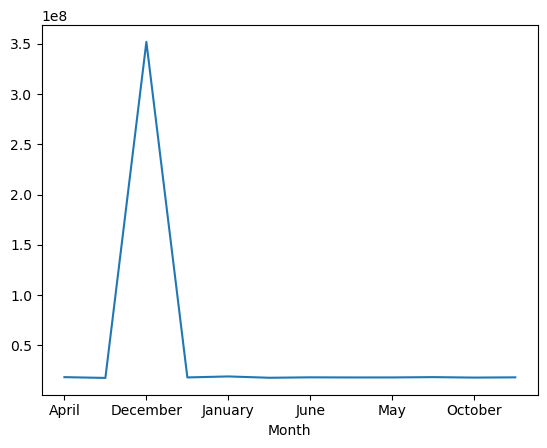

In [32]:
import matplotlib.pyplot as plt

df.groupby('Month')['Revenue'].sum().plot()
plt.show()

In [33]:
# Revenue Volatility
df.groupby('Month')['Revenue'].std()

Month
April        7611.909862
August       7396.483619
December     7545.902034
February     7455.969851
January      7742.195229
July         7126.363288
June         7512.329470
March        7538.999309
May          7655.913549
November     7540.409623
October      7481.445581
September    7667.939344
Name: Revenue, dtype: float64

In [34]:
df.columns

Index(['Date', 'Store ID', 'Product ID', 'Category', 'Region',
       'Inventory Level', 'Units Sold', 'Units Ordered', 'Demand Forecast',
       'Price', 'Discount', 'Weather Condition', 'Holiday/Promotion',
       'Competitor Pricing', 'Seasonality', 'Product_Name', 'Month',
       'Month_Num', 'Weekday', 'Quarter', 'Revenue', 'Cost Price', 'Profit',
       'Profit Margin %', 'Price Difference', 'Price Band', 'Demand Gap'],
      dtype='object')

# SECTION 2 — Demand & Price Sensitivity

In [35]:
# Correlation between Price and Units Sold?

df[['Price', 'Units Sold']].corr()

,Price,Units Sold
Price,1.000000,0.001082
Units Sold,0.001082,1.000000


In [36]:
# Category-wise Elasticity

df.groupby('Category')[['Price','Units Sold']].corr()

Price  Units Sold
Category                                    
Clothing    Price       1.000000   -0.001842
            Units Sold -0.001842    1.000000
Electronics Price       1.000000    0.000149
            Units Sold  0.000149    1.000000
Furniture   Price       1.000000   -0.005234
            Units Sold -0.005234    1.000000
Groceries   Price       1.000000    0.010025
            Units Sold  0.010025    1.000000
Toys        Price       1.000000    0.002442
            Units Sold  0.002442    1.000000

In [37]:
# Demand Across Price Bands

df.groupby('Price Band')['Units Sold'].mean()

C:\Users\ABHISHEK\AppData\Local\Temp\ipykernel_7200\198683738.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('Price Band')['Units Sold'].mean()


Price Band
Low        135.640501
Medium     137.618743
High       135.741556
Premium    136.858425
Name: Units Sold, dtype: float64

In [38]:
# High Price vs Low Price Demand

high_price = df[df['Price'] > df['Price'].median()]
low_price = df[df['Price'] <= df['Price'].median()]

print(high_price['Units Sold'].mean())
print(low_price['Units Sold'].mean())

136.30008210180625
136.62956783369802


# SECTION 3 — Competitor Analysi

In [39]:
#  Competitor Price Correlation

df[['Competitor Pricing', 'Units Sold']].corr()

,Competitor Pricing,Units Sold
Competitor Pricing,1.000000,0.001259
Units Sold,0.001259,1.000000


In [40]:
# Demand Drop when Competitor Cheaper
df[df['Competitor Pricing'] < df['Price']]['Units Sold'].mean()

136.05510668017857

In [41]:
# Category-wise Competitor Sensitivity

df.groupby('Category')[['Competitor Pricing','Units Sold']].corr()

Competitor Pricing  Units Sold
Category                                                      
Clothing    Competitor Pricing            1.000000   -0.001726
            Units Sold                   -0.001726    1.000000
Electronics Competitor Pricing            1.000000    0.001076
            Units Sold                    0.001076    1.000000
Furniture   Competitor Pricing            1.000000   -0.004925
            Units Sold                   -0.004925    1.000000
Groceries   Competitor Pricing            1.000000    0.009950
            Units Sold                    0.009950    1.000000
Toys        Competitor Pricing            1.000000    0.002032
            Units Sold                    0.002032    1.000000

In [42]:
# Monthly demand pattern

df.groupby('Month')['Units Sold'].mean()

Month
April        137.722083
August       134.724167
December     136.898240
February     136.364167
January      136.652400
July         135.011667
June         136.089583
March        134.341667
May          136.024167
November     135.886250
October      133.736250
September    136.138750
Name: Units Sold, dtype: float64

In [43]:
# Monthly revenue Pattern

df.groupby('Month')['Revenue'].sum()

Month
April        1.823581e+07
August       1.746549e+07
December     3.519748e+08
February     1.795917e+07
January      1.894133e+07
July         1.762630e+07
June         1.804893e+07
March        1.792905e+07
May          1.794707e+07
November     1.825860e+07
October      1.780468e+07
September    1.803766e+07
Name: Revenue, dtype: float64

In [44]:
# Peak demand month

df.groupby('Month')['Units Sold'].mean().idxmax()

'April'

In [45]:
# Weekday demand pattern

df.groupby('Weekday')['Units Sold'].mean().idxmax()

'Sunday'

In [46]:
## Inventory Optimization

# Correlation between Inventory and Units Sold

df[['Inventory Level','Units Sold']].corr()

,Inventory Level,Units Sold
Inventory Level,1.000000,0.589995
Units Sold,0.589995,1.000000


In [47]:
# Fast moving products (highest avg units sold)

df.groupby('Product_Name')['Units Sold'].mean().sort_values(ascending=False).head(10)

Product_Name
Sofa Set        138.935361
Cooking Oil     138.914821
Office Chair    138.106180
Dining Table    137.797772
Bed Frame       137.711923
Jacket          137.507366
Wheat Flour     137.306429
Milk Carton     137.298874
Toy Car         137.294263
LED TV          137.259233
Name: Units Sold, dtype: float64

In [48]:
# Slow moving products

df.groupby('Product_Name')['Units Sold'].mean().sort_values().head(10)

Product_Name
Headphones        132.717949
Action Figure     133.748233
Rice Pack         134.240137
Smartphone        134.440054
Gaming Console    134.494206
Doll              135.027055
Sweater           135.651939
Laptop            136.149223
Bookshelf         136.331563
T-Shirt           136.510934
Name: Units Sold, dtype: float64

In [49]:
df.isnull().sum()

Date                    0
Store ID                0
Product ID              0
Category                0
Region                  0
Inventory Level         0
Units Sold              0
Units Ordered           0
Demand Forecast         0
Price                   0
Discount                0
Weather Condition       0
Holiday/Promotion       0
Competitor Pricing      0
Seasonality             0
Product_Name            0
Month                   0
Month_Num               0
Weekday                 0
Quarter                 0
Revenue                 0
Cost Price              0
Profit                  0
Profit Margin %       360
Price Difference        0
Price Band              0
Demand Gap              0
dtype: int64

In [50]:
df[df['Revenue'] == 0]

,Date,Store ID,Product ID,Category,Region,Inventory Level,Units Sold,Units Ordered,Demand Forecast,Price,...,Month_Num,Weekday,Quarter,Revenue,Cost Price,Profit,Profit Margin %,Price Difference,Price Band,Demand Gap
63,2022-01-01,S004,P0004,Groceries,West,437,0,160,-2.40,87.23,...,1,Saturday,1,0.0,46.184724,0.0,NaN,-3.13,Premium,-2.40
159,2022-02-01,S003,P0020,Electronics,East,155,0,92,9.42,57.07,...,2,Tuesday,1,0.0,34.745143,0.0,NaN,3.73,High,9.42
303,2022-04-01,S001,P0004,Electronics,North,209,0,123,15.37,44.81,...,4,Friday,2,0.0,39.769859,0.0,NaN,-0.72,Medium,15.37
1107,2022-12-01,S001,P0008,Clothing,West,432,0,33,-3.55,55.07,...,12,Thursday,4,0.0,45.589457,0.0,NaN,3.92,High,-3.55
1398,2022-12-01,S005,P0019,Groceries,West,65,0,122,-0.03,82.34,...,12,Thursday,4,0.0,43.701062,0.0,NaN,2.54,Premium,-0.03
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
71239,2023-12-12,S002,P0020,Clothing,West,135,0,148,0.35,90.15,...,12,Tuesday,4,0.0,50.355671,0.0,NaN,4.91,Premium,0.35
72053,2023-12-12,S003,P0014,Toys,South,421,0,133,-4.03,11.71,...,12,Tuesday,4,0.0,9.839200,0.0,NaN,-0.40,Low,-4.03
72078,2023-12-12,S004,P0019,Electronics,East,301,0,24,-9.08,59.17,...,12,Tuesday,4,0.0,41.373819,0.0,NaN,1.01,High,-9.08
72463,2023-12-12,S004,P0004,Electronics,North,101,0,70,16.66,72.31,...,12,Tuesday,4,0.0,47.514090,0.0,NaN,-4.62,High,16.66


In [51]:
df['Profit Margin %'] = df['Profit Margin %'].fillna(0)

df.isnull().sum()

Date                  0
Store ID              0
Product ID            0
Category              0
Region                0
Inventory Level       0
Units Sold            0
Units Ordered         0
Demand Forecast       0
Price                 0
Discount              0
Weather Condition     0
Holiday/Promotion     0
Competitor Pricing    0
Seasonality           0
Product_Name          0
Month                 0
Month_Num             0
Weekday               0
Quarter               0
Revenue               0
Cost Price            0
Profit                0
Profit Margin %       0
Price Difference      0
Price Band            0
Demand Gap            0
dtype: int64

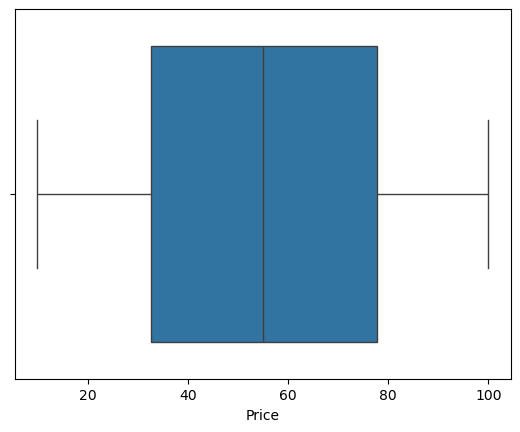

In [52]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(x=df['Price'])
plt.show()

In [53]:
df.columns

Index(['Date', 'Store ID', 'Product ID', 'Category', 'Region',
       'Inventory Level', 'Units Sold', 'Units Ordered', 'Demand Forecast',
       'Price', 'Discount', 'Weather Condition', 'Holiday/Promotion',
       'Competitor Pricing', 'Seasonality', 'Product_Name', 'Month',
       'Month_Num', 'Weekday', 'Quarter', 'Revenue', 'Cost Price', 'Profit',
       'Profit Margin %', 'Price Difference', 'Price Band', 'Demand Gap'],
      dtype='object')

# KPI Card 

In [54]:
print("Total Revenue",df["Revenue"].sum())

Total Revenue 550228884.91


In [55]:
print("Total Profit",df["Profit"].sum())

Total Profit 164948160.65933868


In [56]:
print("Total Profit Margin % -",df["Profit Margin %"].sum())

Total Profit Margin % - 2181781.7286925386


In [57]:
print("Total Unit Sold -",df["Units Sold"].sum())

Total Unit Sold - 9975582


## Profit Analysis

In [58]:
df.groupby("Category")["Profit"].sum()

Category
Clothing       3.294485e+07
Electronics    3.248306e+07
Furniture      3.356532e+07
Groceries      3.305643e+07
Toys           3.289850e+07
Name: Profit, dtype: float64

In [59]:
# Region wise profit

df.groupby("Region")["Profit"].sum()

Region
East     4.172569e+07
North    4.099049e+07
South    4.164419e+07
West     4.058780e+07
Name: Profit, dtype: float64

In [60]:
# top Loss Product

df.groupby("Product_Name")['Profit'].sum().nsmallest(10)

Product_Name
Rice Pack      6.361646e+06
Headphones     6.367328e+06
LED TV         6.371380e+06
Doll           6.394722e+06
T-Shirt        6.438708e+06
Toy Car        6.464650e+06
Wheat Flour    6.498624e+06
Jeans          6.500539e+06
Laptop         6.508692e+06
Sweater        6.517357e+06
Name: Profit, dtype: float64

In [61]:
# Monthly Profit trend

df.groupby("Month")['Profit'].sum()

Month
April        5.485319e+06
August       5.287021e+06
December     1.054660e+08
February     5.330132e+06
January      5.752837e+06
July         5.276559e+06
June         5.444765e+06
March        5.298818e+06
May          5.382504e+06
November     5.517590e+06
October      5.337610e+06
September    5.368994e+06
Name: Profit, dtype: float64

## Alert System 

#### Revenue Drop Alert

In [62]:
df.columns

Index(['Date', 'Store ID', 'Product ID', 'Category', 'Region',
       'Inventory Level', 'Units Sold', 'Units Ordered', 'Demand Forecast',
       'Price', 'Discount', 'Weather Condition', 'Holiday/Promotion',
       'Competitor Pricing', 'Seasonality', 'Product_Name', 'Month',
       'Month_Num', 'Weekday', 'Quarter', 'Revenue', 'Cost Price', 'Profit',
       'Profit Margin %', 'Price Difference', 'Price Band', 'Demand Gap'],
      dtype='object')

In [63]:
df['Month'].isnull().sum()

0

In [64]:
df['High Demand Gap Alert'] = df['Demand Gap'] > df['Demand Gap'].quantile(0.75)

df['Low Sales Alert'] = df['Units Sold'] < df['Units Sold'].quantile(0.25)

In [65]:
print(df['High Demand Gap Alert'].value_counts())
print(df['Low Sales Alert'].value_counts())

High Demand Gap Alert
False    54831
True     18269
Name: count, dtype: int64
Low Sales Alert
False    54837
True     18263
Name: count, dtype: int64


In [66]:
df['Critical Alert'] = (
    (df['Demand Gap'] > df['Demand Gap'].mean()) &
    (df['Units Sold'] < df['Units Sold'].mean())
)

In [67]:
df.columns

Index(['Date', 'Store ID', 'Product ID', 'Category', 'Region',
       'Inventory Level', 'Units Sold', 'Units Ordered', 'Demand Forecast',
       'Price', 'Discount', 'Weather Condition', 'Holiday/Promotion',
       'Competitor Pricing', 'Seasonality', 'Product_Name', 'Month',
       'Month_Num', 'Weekday', 'Quarter', 'Revenue', 'Cost Price', 'Profit',
       'Profit Margin %', 'Price Difference', 'Price Band', 'Demand Gap',
       'High Demand Gap Alert', 'Low Sales Alert', 'Critical Alert'],
      dtype='object')

In [68]:
monthly = df.groupby(['Month_Num','Month']).agg({
    'Revenue':'sum',
    'Profit':'sum'
}).reset_index().sort_values('Month_Num')





In [69]:
monthly['Revenue_Change_pct'] = monthly['Revenue'].pct_change() * 100
monthly['Profit_Change_pct'] = monthly['Profit'].pct_change() * 100

In [70]:
monthly['Revenue_Alert'] = monthly['Revenue_Change_pct'] < -5
monthly['Profit_Alert'] = monthly['Profit_Change_pct'] < -5


In [71]:
row_alerts = df[
    (df['High Demand Gap Alert']) |
    (df['Low Sales Alert'])
]

monthly_alerts = monthly[
    (monthly['Revenue_Alert']) |
    (monthly['Profit_Alert'])
]

In [72]:
print(row_alerts.head())

print(monthly_alerts.head())

         Date Store ID Product ID     Category Region  Inventory Level  \
4  2022-01-01     S001      P0005  Electronics   East              166   
7  2022-01-01     S001      P0008     Clothing  North              380   
9  2022-01-01     S001      P0010         Toys  South              108   
11 2022-01-01     S001      P0012     Clothing   West               66   
12 2022-01-01     S001      P0013         Toys  South               96   

    Units Sold  Units Ordered  Demand Forecast  Price  ...   Revenue  \
4           14            135             9.26  73.64  ...   1030.96   
7          312             54           329.73  97.99  ...  30572.88   
9           28            196            24.47  59.99  ...   1679.72   
11          24             70            26.75  58.25  ...   1398.00   
12          42             85            41.46  43.60  ...   1831.20   

   Cost Price       Profit  Profit Margin % Price Difference Price Band  \
4   43.034834   428.472330        41.560519    

In [73]:
monthly

,Month_Num,Month,Revenue,Profit,Revenue_Change_pct,Profit_Change_pct,Revenue_Alert,Profit_Alert
0,1,January,1.894133e+07,5.752837e+06,NaN,NaN,False,False
1,2,February,1.795917e+07,5.330132e+06,-5.185252,-7.347767,True,True
2,3,March,1.792905e+07,5.298818e+06,-0.167712,-0.587485,False,False
3,4,April,1.823581e+07,5.485319e+06,1.710975,3.519653,False,False
4,5,May,1.794707e+07,5.382504e+06,-1.583382,-1.874351,False,False
5,6,June,1.804893e+07,5.444765e+06,0.567554,1.156717,False,False
6,7,July,1.762630e+07,5.276559e+06,-2.341598,-3.089307,False,False
7,8,August,1.746549e+07,5.287021e+06,-0.912308,0.198261,False,False
8,9,September,1.803766e+07,5.368994e+06,3.275996,1.550461,False,False
9,10,October,1.780468e+07,5.337610e+06,-1.291619,-0.584533,False,False


In [74]:
monthly.to_csv("monthly_data.csv", index=False)

In [75]:
with pd.ExcelWriter("Ecommerce_Data.xlsx") as writer:
    df.to_excel(writer, sheet_name="final_data", index=False)
    monthly.to_excel(writer, sheet_name="monthly_data", index=False)

In [76]:
df.columns

Index(['Date', 'Store ID', 'Product ID', 'Category', 'Region',
       'Inventory Level', 'Units Sold', 'Units Ordered', 'Demand Forecast',
       'Price', 'Discount', 'Weather Condition', 'Holiday/Promotion',
       'Competitor Pricing', 'Seasonality', 'Product_Name', 'Month',
       'Month_Num', 'Weekday', 'Quarter', 'Revenue', 'Cost Price', 'Profit',
       'Profit Margin %', 'Price Difference', 'Price Band', 'Demand Gap',
       'High Demand Gap Alert', 'Low Sales Alert', 'Critical Alert'],
      dtype='object')